# Task 0 — Decision Tree

**Name:** Abdlrhman Hisham Ismail · **ID:** AI2617

Train a Decision Tree on **Red Wine Quality** (binary: good if `quality >= 6`) and study how **F1-score** changes with `max_depth` from **3 to 25**.

Produce **two graphs**:
1. Train F1 vs max_depth  
2. Test F1 vs max_depth  


## Setup

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if "Task" in Path.cwd().name else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report

from data_utils import load_wine_binary, dataset_info

print(dataset_info())
X_train, X_test, y_train, y_test = load_wine_binary()
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Class balance (train):", y_train.value_counts().to_dict())


Red Wine Quality (UCI / Kaggle) — binary label: good wine if quality >= 6. Features: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free/total sulfur dioxide, density, pH, sulphates, alcohol.
Train: (1199, 11) | Test: (400, 11)
Class balance (train): {1: 641, 0: 558}


## Sweep `max_depth` = 3 … 25

In [2]:
depths = list(range(3, 26))
train_f1, test_f1 = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_f1.append(f1_score(y_train, clf.predict(X_train)))
    test_f1.append(f1_score(y_test, clf.predict(X_test)))
    print(f"depth={d:2d} | train F1={train_f1[-1]:.4f} | test F1={test_f1[-1]:.4f}")

results = pd.DataFrame({"max_depth": depths, "train_F1": train_f1, "test_F1": test_f1})
best = results.loc[results["test_F1"].idxmax()]
print(f"\nBest depth by test F1: {int(best.max_depth)} (test F1={best.test_F1:.4f})")
results.to_csv("results_f1_vs_depth.csv", index=False)
display(results.round(4))


depth= 3 | train F1=0.7651 | test F1=0.7540
depth= 4 | train F1=0.7928 | test F1=0.7482
depth= 5 | train F1=0.8097 | test F1=0.7506
depth= 6 | train F1=0.8382 | test F1=0.7423
depth= 7 | train F1=0.8790 | test F1=0.7448
depth= 8 | train F1=0.9149 | test F1=0.7431
depth= 9 | train F1=0.9397 | test F1=0.7540
depth=10 | train F1=0.9565 | test F1=0.7588
depth=11 | train F1=0.9714 | test F1=0.7517
depth=12 | train F1=0.9851 | test F1=0.7551
depth=13 | train F1=0.9930 | test F1=0.7654
depth=14 | train F1=0.9969 | test F1=0.7602
depth=15 | train F1=0.9992 | test F1=0.7591
depth=16 | train F1=1.0000 | test F1=0.7580
depth=17 | train F1=1.0000 | test F1=0.7580
depth=18 | train F1=1.0000 | test F1=0.7580
depth=19 | train F1=1.0000 | test F1=0.7580
depth=20 | train F1=1.0000 | test F1=0.7580
depth=21 | train F1=1.0000 | test F1=0.7580
depth=22 | train F1=1.0000 | test F1=0.7580
depth=23 | train F1=1.0000 | test F1=0.7580
depth=24 | train F1=1.0000 | test F1=0.7580
depth=25 | train F1=1.0000 | tes

,max_depth,train_F1,test_F1
0,3,0.7651,0.7540
1,4,0.7928,0.7482
2,5,0.8097,0.7506
3,6,0.8382,0.7423
4,7,0.8790,0.7448
5,8,0.9149,0.7431
6,9,0.9397,0.7540
7,10,0.9565,0.7588
8,11,0.9714,0.7517
9,12,0.9851,0.7551


## Graph 1 — Train F1 vs max_depth

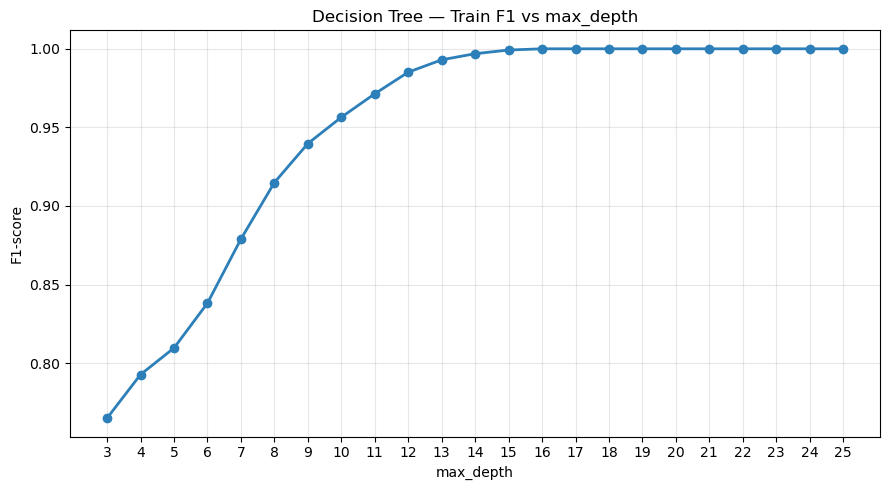

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results["max_depth"], results["train_F1"], "o-", color="#2c7fb8", lw=2)
ax.set_xlabel("max_depth")
ax.set_ylabel("F1-score")
ax.set_title("Decision Tree — Train F1 vs max_depth")
ax.set_xticks(depths)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("plots/train_f1_vs_max_depth.png", dpi=150)
plt.show()


## Graph 2 — Test F1 vs max_depth

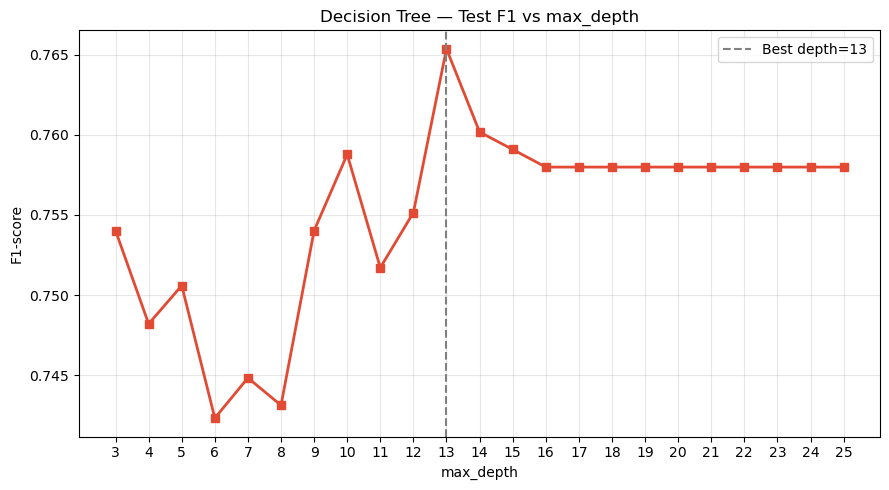

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results["max_depth"], results["test_F1"], "s-", color="#e34a33", lw=2)
ax.axvline(best.max_depth, color="gray", ls="--", label=f"Best depth={int(best.max_depth)}")
ax.set_xlabel("max_depth")
ax.set_ylabel("F1-score")
ax.set_title("Decision Tree — Test F1 vs max_depth")
ax.set_xticks(depths)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("plots/test_f1_vs_max_depth.png", dpi=150)
plt.show()


## Observation

As `max_depth` grows, **train F1** typically rises (more capacity → fit the training set).  
**Test F1** usually peaks then plateaus or drops — the classic bias–variance trade-off / overfitting signal.
